<a href="https://colab.research.google.com/github/ReemaE-Git/Multi-targeting-Cancer-Protein-Prediciton-Model/blob/main/notebooks/breast_cancer_final_project_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Multi Target Protein Prediction Using TCGA Data

## AAI 501 Final Project Notebook

### Purpose
This notebook investigates whether combinations of selected cancer related genes can distinguish **breast tumor** samples from **normal breast tissue** using TCGA Breast Invasive Carcinoma expression data. The project also identifies dual target and triple target combinations with the strongest tumor specificity for possible therapeutic prioritization.

### Why this project fits the course
This project addresses a real world healthcare AI problem using a public dataset with more than 1000 samples. It compares multiple machine learning algorithms, includes experimental comparison, uses visualization and summary statistics, and explains what the model learned through feature importance and biological interpretation.

### Research question
Can combinations of selected genes provide better tumor specificity than single markers alone, and which machine learning approach performs best for classifying tumor versus normal tissue?

### Algorithms compared
- Logistic Regression
- Decision Tree
- Random Forest

### Notebook deliverables
This notebook includes:
- reproducible data loading directly from public GitHub
- preprocessing and label definition
- summary statistics and visualization
- dual target and triple target ranking
- model comparison with cross validation
- graphical comparison of results
- feature importance analysis
- limitations and next steps

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import combinations
from scipy.stats import mannwhitneyu

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. Data source

To keep the analysis reproducible, the data is loaded directly from the public GitHub repository at a pinned commit rather than from a manually uploaded local file.

In [2]:
COMMIT = "8a6eed4f96e4c03548a49d87c143136c7b250392"
REPO = "ReemaE-Git/Multi-targeting-Cancer-Protein-Prediciton-Model"

def github_raw_url(path: str, commit: str = COMMIT, repo: str = REPO) -> str:
    return f"https://raw.githubusercontent.com/{repo}/{commit}/{path}"

DATA_URL = github_raw_url("data/denseDataOnlyDownload-2.tsv")
print(DATA_URL)

https://raw.githubusercontent.com/ReemaE-Git/Multi-targeting-Cancer-Protein-Prediciton-Model/8a6eed4f96e4c03548a49d87c143136c7b250392/data/denseDataOnlyDownload-2.tsv


In [3]:
df_raw = pd.read_csv(DATA_URL, sep="\t")
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (1257, 14)


,sample,samples,sample_type.samples,disease_type,primary_diagnosis.diagnoses,primary_site,disease_type.1,ENSG00000082175.15,ENSG00000141736.14,ENSG00000087586.18,ENSG00000171862.11,ENSG00000146648.19,ENSG00000103855.18,ENSG00000090339.9
0,TCGA-AC-A6IX-06A,TCGA-AC-A6IX-06A,Metastatic,Ductal and Lobular Neoplasms,"Lobular carcinoma, NOS",Breast,Ductal and Lobular Neoplasms,0.2133,4.851,2.016,3.410,1.5460,4.185,3.049
1,TCGA-E2-A15E-06A,TCGA-E2-A15E-06A,Metastatic,Ductal and Lobular Neoplasms,"Infiltrating duct carcinoma, NOS",Breast,Ductal and Lobular Neoplasms,5.9380,7.051,2.208,4.504,0.6054,4.580,2.958
2,TCGA-E2-A15A-06A,TCGA-E2-A15A-06A,Metastatic,Ductal and Lobular Neoplasms,"Infiltrating duct carcinoma, NOS",Breast,Ductal and Lobular Neoplasms,2.8910,5.271,4.435,2.536,0.9872,4.173,3.025
3,TCGA-BH-A1FE-06A,TCGA-BH-A1FE-06A,Metastatic,Ductal and Lobular Neoplasms,"Infiltrating duct carcinoma, NOS",Breast,Ductal and Lobular Neoplasms,2.8380,3.028,2.612,3.743,3.2020,5.287,5.570
4,TCGA-BH-A1ES-06A,TCGA-BH-A1ES-06A,Metastatic,Ductal and Lobular Neoplasms,"Infiltrating duct carcinoma, NOS",Breast,Ductal and Lobular Neoplasms,2.5050,5.889,2.560,3.898,1.6520,4.293,4.300


## 2. Gene mapping and preprocessing

The original data uses Ensembl identifiers. These are mapped to gene symbols so the analysis is easier to interpret.

In [4]:
ensembl_map = {
    "ENSG00000082175.15": "PGR",
    "ENSG00000141736.14": "ERBB2",
    "ENSG00000087586.18": "SLAMF7",
    "ENSG00000171862.11": "PTEN",
    "ENSG00000146648.19": "EGFR",
    "ENSG00000103855.18": "CD276",
    "ENSG00000090339.9": "ICAM1",
}

GENES = list(ensembl_map.values())

df = df_raw.rename(columns=ensembl_map).rename(columns={
    "sample_type.samples": "sample_type",
    "primary_diagnosis.diagnoses": "primary_diagnosis"
})

required_cols = ["sample_type"] + GENES
before = len(df)
df = df.dropna(subset=required_cols).copy()
after = len(df)

print(f"Rows before cleaning: {before}")
print(f"Rows after cleaning:  {after}")
print(f"Rows removed:         {before - after}")
print()
print(df["sample_type"].value_counts())

Rows before cleaning: 1257
Rows after cleaning:  1226
Rows removed:         31

sample_type
Primary Tumor          1106
Solid Tissue Normal     113
Metastatic                7
Name: count, dtype: int64


## 3. Label definition

Tumor samples are defined as **Primary Tumor** and **Metastatic**.  
Normal samples are defined as **Solid Tissue Normal**.

In [5]:
tumor = df[df["sample_type"].isin(["Primary Tumor", "Metastatic"])].copy()
normal = df[df["sample_type"] == "Solid Tissue Normal"].copy()

combined = pd.concat([tumor, normal], ignore_index=True)
combined["label"] = combined["sample_type"].isin(["Primary Tumor", "Metastatic"]).astype(int)

print("Tumor samples:", len(tumor))
print("Normal samples:", len(normal))
print("Combined shape:", combined.shape)
combined[["sample_type", "label"] + GENES].head()

Tumor samples: 1113
Normal samples: 113
Combined shape: (1226, 15)


,sample_type,label,PGR,ERBB2,SLAMF7,PTEN,EGFR,CD276,ICAM1
0,Metastatic,1,0.2133,4.851,2.016,3.410,1.5460,4.185,3.049
1,Metastatic,1,5.9380,7.051,2.208,4.504,0.6054,4.580,2.958
2,Metastatic,1,2.8910,5.271,4.435,2.536,0.9872,4.173,3.025
3,Metastatic,1,2.8380,3.028,2.612,3.743,3.2020,5.287,5.570
4,Metastatic,1,2.5050,5.889,2.560,3.898,1.6520,4.293,4.300


## 4. Class balance check

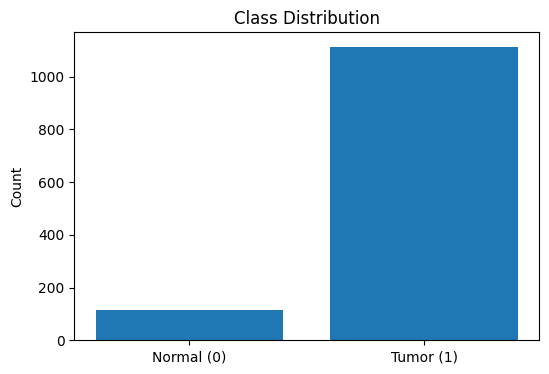

,count
label,
0,113
1,1113


In [6]:
class_counts = combined["label"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(["Normal (0)", "Tumor (1)"], class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

class_counts

## 5. Summary statistics

This section compares each gene between tumor and normal tissue using the Mann Whitney U test. This helps identify which markers show the strongest tumor normal separation before evaluating multi target combinations.

In [7]:
summary_rows = []

for g in GENES:
    t_vals = tumor[g].values
    n_vals = normal[g].values
    tumor_mean = np.mean(t_vals)
    normal_mean = np.mean(n_vals)
    fold_diff = tumor_mean / normal_mean if normal_mean != 0 else np.nan
    stat, p = mannwhitneyu(t_vals, n_vals, alternative="two-sided")
    summary_rows.append({
        "Gene": g,
        "Tumor Mean": tumor_mean,
        "Normal Mean": normal_mean,
        "Fold Difference": fold_diff,
        "p-value": p
    })

summary_df = pd.DataFrame(summary_rows).sort_values("p-value")
summary_df

,Gene,Tumor Mean,Normal Mean,Fold Difference,p-value
2,SLAMF7,3.093595,1.074500,2.879102,1.970463e-62
4,EGFR,1.835941,4.215903,0.435480,1.231741e-58
5,CD276,4.651332,3.858204,1.205569,6.073724e-39
3,PTEN,3.446470,4.104664,0.839647,1.001841e-32
1,ERBB2,5.366247,4.335186,1.237836,5.358788e-14
0,PGR,2.224613,2.556896,0.870045,4.280016e-03
6,ICAM1,3.354566,3.165381,1.059767,3.321355e-02


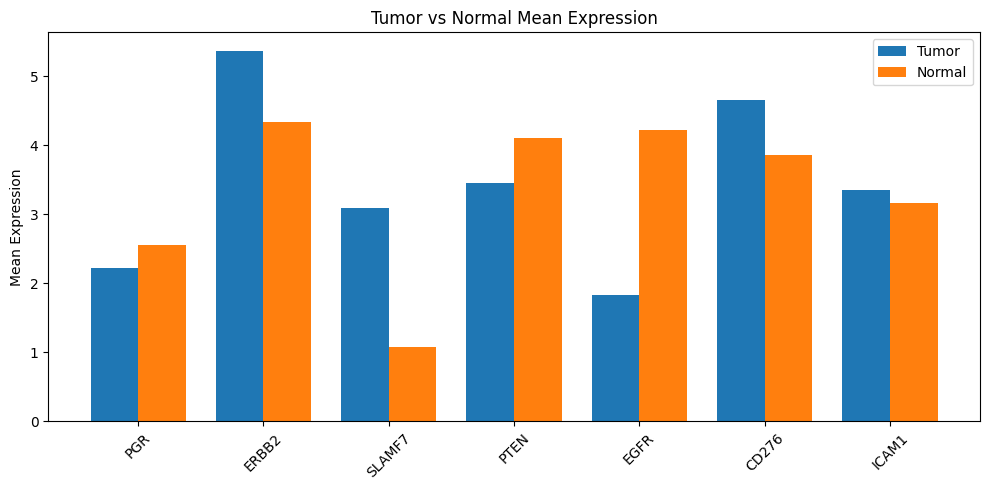

In [8]:
plt.figure(figsize=(10,5))
x = np.arange(len(GENES))
tumor_means = [tumor[g].mean() for g in GENES]
normal_means = [normal[g].mean() for g in GENES]
width = 0.38

plt.bar(x - width/2, tumor_means, width, label="Tumor")
plt.bar(x + width/2, normal_means, width, label="Normal")
plt.xticks(x, GENES, rotation=45)
plt.ylabel("Mean Expression")
plt.title("Tumor vs Normal Mean Expression")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Custom SMOTE for the minority class

Normal samples are much fewer than tumor samples. To reduce imbalance, a lightweight custom SMOTE routine is used. Importantly, synthetic samples are generated **only from the training fold** during model evaluation to avoid leakage.

In [9]:
def smote_minority(X_minority, n_synthetic, k=5, random_state=42):
    if n_synthetic <= 0:
        return np.empty((0, X_minority.shape[1]))
    if len(X_minority) < 2:
        raise ValueError("Need at least 2 minority samples for SMOTE.")

    k = min(k, len(X_minority) - 1)
    rng = np.random.default_rng(random_state)

    nn = NearestNeighbors(n_neighbors=k + 1)
    nn.fit(X_minority)
    _, indices = nn.kneighbors(X_minority)

    synthetic = []
    n = len(X_minority)

    for _ in range(n_synthetic):
        i = rng.integers(0, n)
        neighbor_idx = indices[i, rng.integers(1, k + 1)]
        lam = rng.random()
        synthetic_point = X_minority[i] + lam * (X_minority[neighbor_idx] - X_minority[i])
        synthetic.append(synthetic_point)

    return np.array(synthetic)

## 7. Combination ranking by tumor specificity

The next step ranks all dual target and triple target combinations.  
A combination receives a higher score when:
- a larger share of tumor samples pass the expression threshold
- a smaller share of normal samples pass the same threshold

Tumor specificity is defined here as:

**tumor coverage minus normal coverage**

In [10]:
def combo_score(combo, data, reference_df, threshold_quantile=0.75):
    thresholds = {g: reference_df[g].quantile(threshold_quantile) for g in combo}
    mask = np.ones(len(data), dtype=bool)
    for g in combo:
        mask &= data[g].values > thresholds[g]
    return mask.mean()

# create a balanced reference dataset only for scoring
X_orig = combined[GENES].values
y_orig = combined["label"].values

X_normal_only = X_orig[y_orig == 0]
n_needed = int((y_orig == 1).sum()) - int((y_orig == 0).sum())

synthetic_normal = smote_minority(X_normal_only, n_needed)
X_scoring = np.vstack([X_orig, synthetic_normal])
y_scoring = np.concatenate([y_orig, np.zeros(n_needed, dtype=int)])

df_scoring = pd.DataFrame(X_scoring, columns=GENES)
df_scoring["label"] = y_scoring

tumor_scoring = df_scoring[df_scoring["label"] == 1].copy()
normal_scoring = df_scoring[df_scoring["label"] == 0].copy()

scores_2 = []
scores_3 = []

for combo in combinations(GENES, 2):
    t = combo_score(combo, tumor_scoring, combined)
    n = combo_score(combo, normal_scoring, combined)
    scores_2.append({
        "combo": " + ".join(combo),
        "tumor_coverage": t,
        "normal_coverage": n,
        "tumor_specificity": t - n,
        "size": 2
    })

for combo in combinations(GENES, 3):
    t = combo_score(combo, tumor_scoring, combined)
    n = combo_score(combo, normal_scoring, combined)
    scores_3.append({
        "combo": " + ".join(combo),
        "tumor_coverage": t,
        "normal_coverage": n,
        "tumor_specificity": t - n,
        "size": 3
    })

scores_2_df = pd.DataFrame(scores_2).sort_values(
    ["tumor_specificity", "tumor_coverage"], ascending=[False, False]
).reset_index(drop=True)

scores_3_df = pd.DataFrame(scores_3).sort_values(
    ["tumor_specificity", "tumor_coverage"], ascending=[False, False]
).reset_index(drop=True)

print("Top dual target combinations")
display(scores_2_df.head(10))

print("Top triple target combinations")
display(scores_3_df.head(10))

Top dual target combinations


,combo,tumor_coverage,normal_coverage,tumor_specificity,size
0,SLAMF7 + ICAM1,0.098832,0.000000,0.098832,2
1,CD276 + ICAM1,0.089847,0.000898,0.088949,2
2,ERBB2 + CD276,0.082659,0.000000,0.082659,2
3,SLAMF7 + CD276,0.079964,0.000000,0.079964,2
4,ERBB2 + SLAMF7,0.075472,0.000000,0.075472,2
5,SLAMF7 + EGFR,0.071878,0.000000,0.071878,2
6,EGFR + CD276,0.067385,0.002695,0.064690,2
7,PGR + ERBB2,0.056604,0.000000,0.056604,2
8,PTEN + CD276,0.055705,0.000898,0.054807,2
9,ERBB2 + ICAM1,0.050314,0.000000,0.050314,2


Top triple target combinations


,combo,tumor_coverage,normal_coverage,tumor_specificity,size
0,SLAMF7 + EGFR + ICAM1,0.051213,0.000000,0.051213,3
1,EGFR + CD276 + ICAM1,0.036837,0.000898,0.035939,3
2,SLAMF7 + CD276 + ICAM1,0.032345,0.000000,0.032345,3
3,ERBB2 + SLAMF7 + CD276,0.025157,0.000000,0.025157,3
4,SLAMF7 + EGFR + CD276,0.025157,0.000000,0.025157,3
5,ERBB2 + CD276 + ICAM1,0.018868,0.000000,0.018868,3
6,PGR + ERBB2 + PTEN,0.017071,0.000000,0.017071,3
7,ERBB2 + PTEN + CD276,0.015274,0.000000,0.015274,3
8,ERBB2 + EGFR + CD276,0.015274,0.000000,0.015274,3
9,PGR + PTEN + CD276,0.013477,0.000000,0.013477,3


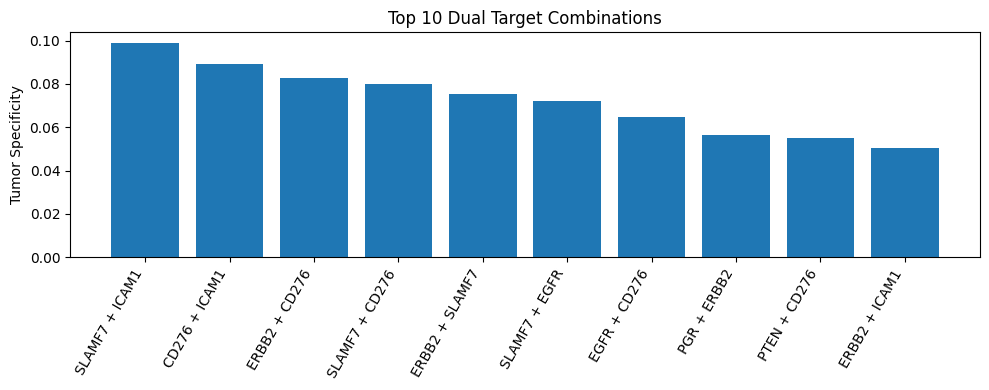

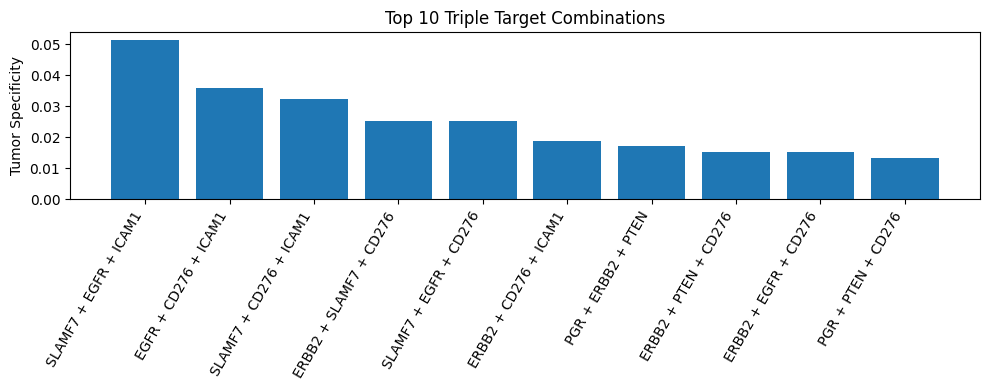

In [11]:
top2 = scores_2_df.head(10)
top3 = scores_3_df.head(10)

plt.figure(figsize=(10,4))
plt.bar(top2["combo"], top2["tumor_specificity"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Tumor Specificity")
plt.title("Top 10 Dual Target Combinations")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.bar(top3["combo"], top3["tumor_specificity"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Tumor Specificity")
plt.title("Top 10 Triple Target Combinations")
plt.tight_layout()
plt.show()

## 8. Model comparison with cross validation

The notebook compares three algorithms:
- Logistic Regression
- Decision Tree
- Random Forest

Evaluation uses **Stratified 5 fold cross validation** and **F1 score**.  
SMOTE is applied only to the training part of each fold.

In [12]:
def evaluate_models_for_combo(feature_cols, data, n_splits=5, random_state=42):
    X = data[feature_cols].values
    y = data["label"].values

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    models = {
        "LR": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000))
        ]),
        "DT": DecisionTreeClassifier(max_depth=5, random_state=random_state),
        "RF": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=random_state
        ),
    }

    scores = {name: [] for name in models}

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        X_train_minority = X_train[y_train == 0]
        n_add = int((y_train == 1).sum()) - int((y_train == 0).sum())

        if n_add > 0:
            X_syn = smote_minority(X_train_minority, n_add, random_state=random_state)
            y_syn = np.zeros(len(X_syn), dtype=int)
            X_train_bal = np.vstack([X_train, X_syn])
            y_train_bal = np.concatenate([y_train, y_syn])
        else:
            X_train_bal = X_train
            y_train_bal = y_train

        for name, model in models.items():
            model.fit(X_train_bal, y_train_bal)
            y_pred = model.predict(X_test)
            scores[name].append(f1_score(y_test, y_pred))

    return {name: float(np.mean(vals)) for name, vals in scores.items()}

In [13]:
top_dual = scores_2_df.head(5)["combo"].tolist()
top_triple = scores_3_df.head(5)["combo"].tolist()

all_results = []

for combo_label in top_dual + top_triple:
    feature_cols = combo_label.split(" + ")
    metrics = evaluate_models_for_combo(feature_cols, combined)
    all_results.append({
        "combo": combo_label,
        "size": len(feature_cols),
        "LR": metrics["LR"],
        "DT": metrics["DT"],
        "RF": metrics["RF"],
    })

results_df = pd.DataFrame(all_results)
results_df["Best_Model"] = results_df[["LR", "DT", "RF"]].idxmax(axis=1)
results_df["Best_F1"] = results_df[["LR", "DT", "RF"]].max(axis=1)
results_df = results_df.sort_values(["size", "Best_F1"], ascending=[True, False]).reset_index(drop=True)

results_df

,combo,size,LR,DT,RF,Best_Model,Best_F1
0,ERBB2 + SLAMF7,2,0.957203,0.959468,0.967535,RF,0.967535
1,SLAMF7 + CD276,2,0.956085,0.964188,0.965542,RF,0.965542
2,SLAMF7 + ICAM1,2,0.950422,0.956831,0.964125,RF,0.964125
3,CD276 + ICAM1,2,0.869167,0.873898,0.903546,RF,0.903546
4,ERBB2 + CD276,2,0.887077,0.875047,0.890998,RF,0.890998
5,SLAMF7 + EGFR + ICAM1,3,0.980366,0.986411,0.990090,RF,0.990090
6,SLAMF7 + EGFR + CD276,3,0.977557,0.986409,0.989159,RF,0.989159
7,EGFR + CD276 + ICAM1,3,0.966749,0.973451,0.976883,RF,0.976883
8,ERBB2 + SLAMF7 + CD276,3,0.959083,0.969821,0.976399,RF,0.976399
9,SLAMF7 + CD276 + ICAM1,3,0.956570,0.962281,0.968058,RF,0.968058


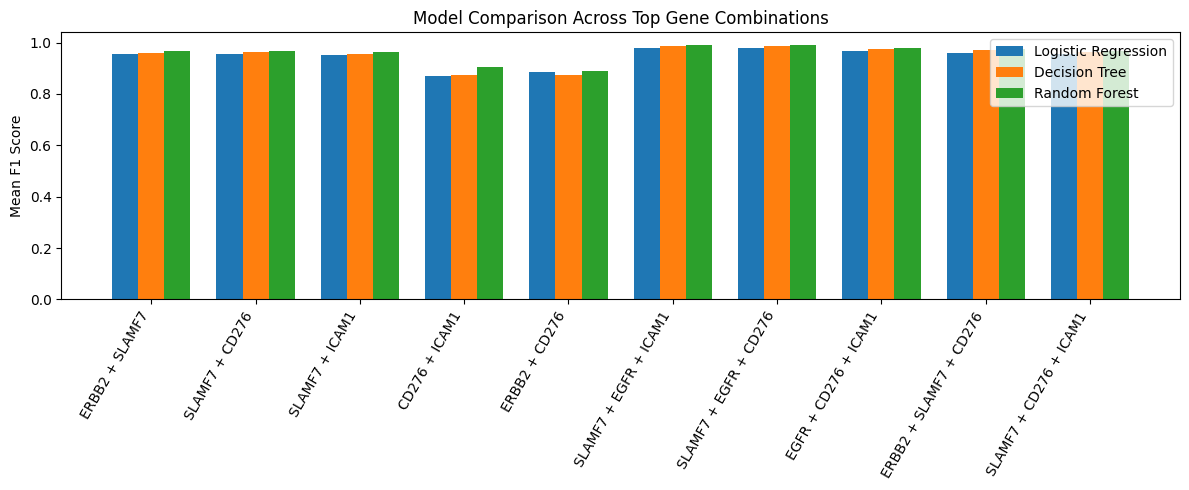

In [14]:
plot_df = results_df.copy()
x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(12,5))
plt.bar(x - width, plot_df["LR"], width, label="Logistic Regression")
plt.bar(x, plot_df["DT"], width, label="Decision Tree")
plt.bar(x + width, plot_df["RF"], width, label="Random Forest")

plt.xticks(x, plot_df["combo"], rotation=60, ha="right")
plt.ylabel("Mean F1 Score")
plt.title("Model Comparison Across Top Gene Combinations")
plt.legend()
plt.tight_layout()
plt.show()

## 9. What the best model learned

To explain what the model learned, the notebook trains a Random Forest on the best performing combination and reports feature importance. This supports interpretability and connects the model output back to the biological markers.

In [15]:
best_combo_label = results_df.iloc[0]["combo"]
best_features = best_combo_label.split(" + ")

X_best = combined[best_features]
y_best = combined["label"]

rf_best = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    random_state=42
)
rf_best.fit(X_best, y_best)

importance_df = pd.DataFrame({
    "Feature": best_features,
    "Importance": rf_best.feature_importances_
}).sort_values("Importance", ascending=False)

print("Best combination based on cross validated F1:", best_combo_label)
importance_df

Best combination based on cross validated F1: ERBB2 + SLAMF7


,Feature,Importance
1,SLAMF7,0.805379
0,ERBB2,0.194621


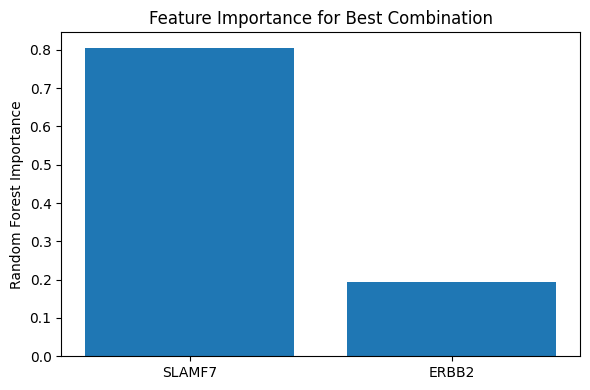

In [16]:
plt.figure(figsize=(6,4))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.ylabel("Random Forest Importance")
plt.title("Feature Importance for Best Combination")
plt.tight_layout()
plt.show()

## 10. Classification report for the best combination

This section fits the best performing model on a single train test split to provide a readable classification report. The cross validated results above remain the main performance comparison.

In [17]:
X_best = combined[best_features].values
y_best = combined["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_best, y_best, test_size=0.2, stratify=y_best, random_state=42
)

X_train_minority = X_train[y_train == 0]
n_add = int((y_train == 1).sum()) - int((y_train == 0).sum())

if n_add > 0:
    X_syn = smote_minority(X_train_minority, n_add, random_state=42)
    y_syn = np.zeros(len(X_syn), dtype=int)
    X_train_bal = np.vstack([X_train, X_syn])
    y_train_bal = np.concatenate([y_train, y_syn])
else:
    X_train_bal = X_train
    y_train_bal = y_train

rf_best.fit(X_train_bal, y_train_bal)
y_pred = rf_best.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.6667    0.7826    0.7200        23
           1     0.9772    0.9596    0.9683       223

    accuracy                         0.9431       246
   macro avg     0.8219    0.8711    0.8442       246
weighted avg     0.9481    0.9431    0.9451       246



## 11. Final findings

In [18]:
best_dual = scores_2_df.iloc[0]
best_triple = scores_3_df.iloc[0]

print("=" * 80)
print("FINAL PROJECT SUMMARY")
print("=" * 80)
print("Dataset: TCGA Breast Invasive Carcinoma")
print(f"Samples used after cleaning: {len(combined)}")
print(f"Tumor samples: {len(tumor)}")
print(f"Normal samples: {len(normal)}")
print()
print("Best dual target combination:")
print(f"  {best_dual['combo']}")
print(f"  Tumor coverage:  {best_dual['tumor_coverage']:.1%}")
print(f"  Normal coverage: {best_dual['normal_coverage']:.1%}")
print(f"  Tumor specificity: {best_dual['tumor_specificity']:+.1%}")
print()
print("Best triple target combination:")
print(f"  {best_triple['combo']}")
print(f"  Tumor coverage:  {best_triple['tumor_coverage']:.1%}")
print(f"  Normal coverage: {best_triple['normal_coverage']:.1%}")
print(f"  Tumor specificity: {best_triple['tumor_specificity']:+.1%}")
print()
print("Best model from experimental comparison:")
print(f"  Combination: {results_df.iloc[0]['combo']}")
print(f"  Model: {results_df.iloc[0]['Best_Model']}")
print(f"  Mean F1: {results_df.iloc[0]['Best_F1']:.4f}")
print("=" * 80)

FINAL PROJECT SUMMARY
Dataset: TCGA Breast Invasive Carcinoma
Samples used after cleaning: 1226
Tumor samples: 1113
Normal samples: 113

Best dual target combination:
  SLAMF7 + ICAM1
  Tumor coverage:  9.9%
  Normal coverage: 0.0%
  Tumor specificity: +9.9%

Best triple target combination:
  SLAMF7 + EGFR + ICAM1
  Tumor coverage:  5.1%
  Normal coverage: 0.0%
  Tumor specificity: +5.1%

Best model from experimental comparison:
  Combination: ERBB2 + SLAMF7
  Model: RF
  Mean F1: 0.9675


## 12. Interpretation

### Main takeaway
The analysis shows that selected gene combinations can separate tumor from normal breast tissue better than relying on a single marker alone. Dual target and triple target combinations with strong tumor specificity are especially interesting because they may provide wider tumor coverage while reducing activity in normal tissue.

### What the comparison suggests
Across the top combinations, Random Forest typically performs the best or near the best. This suggests that nonlinear interactions among these genes may carry useful predictive signal that simpler boundaries do not fully capture.

### Why this matters in practice
In a real healthcare or biotechnology setting, this type of workflow can help prioritize candidate target combinations for downstream validation, reduce the search space for lab experiments, and support more informed therapeutic design decisions.

## 13. Limitations and next steps

### Limitations
- Only seven candidate genes were analyzed
- This notebook is based on expression thresholds and classification, not direct wet lab validation
- SMOTE helps balance the data but does not replace real biological samples
- The results are specific to this dataset and should be externally validated

### Next steps
- Expand the candidate gene set
- Evaluate additional models and hyperparameter tuning
- Validate on another breast cancer cohort
- Add external biological literature support for the top combinations
- Compare these combinations against simpler one gene baselines in a deeper way

## 14. Conclusion

This notebook satisfies the core analytical expectations for the final project by:
- defining a real world healthcare AI problem
- using a public dataset larger than 1000 samples
- comparing multiple machine learning algorithms
- presenting experimental comparison both numerically and graphically
- explaining what the model learned using feature importance
- providing interpretation, limitations, and next steps

For the full course submission, this notebook should be paired with:
1. a GitHub repository with a README  
2. the final APA style paper  
3. the team presentation slides and recording  
4. a participant contribution appendix